# Módulo 3 — Do NLP Clássico à IA Generativa
## Exercício Prático: Transformers · Sentence Embeddings · RAG · Prompting

**Prof. Gabriel Antunes | Data Science Analytics**

---

### Objetivos
1. Usar HuggingFace `pipeline` para sentiment analysis na Olist
2. Gerar embeddings contextuais com `sentence-transformers`
3. Implementar RAG simples (retrieval por cosine similarity)
4. Experimentar zero-shot, few-shot e chain-of-thought
5. Comparativo final M1→M3: TF-IDF vs SVD vs W2V vs Transformers

### Pré-requisito
- Dataset `olist_order_reviews_dataset.csv` na pasta
- Resultados dos Módulos 1 e 2 salvos em `resultados` dict

In [23]:
# ╔══════════════════════════════════════════════════════════╗
# ║  VERSÕES DAS BIBLIOTECAS                                 ║
# ╚══════════════════════════════════════════════════════════╝
#
#  transformers       4.40.x  — HuggingFace pipeline, AutoModel
#  sentence-transformers 2.7.x — embeddings de sentenças
#  torch               2.2.x  — backend dos modelos HF
#  huggingface_hub     0.24.x — download de modelos
#  pandas              2.2.x  — manipulação de dados
#  numpy               1.26.x — álgebra linear
#  scikit-learn        1.4.x  — métricas e cosine_similarity
#  matplotlib          3.8.x  — visualizações
#  nltk                3.8.x  — pré-processamento PT
#  openai              1.x.x  — API OpenAI (Parte 4, opcional)

!pip install transformers sentence-transformers torch huggingface_hub \
             pandas numpy scikit-learn matplotlib nltk --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import numpy as np
import re, time, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

from transformers import pipeline
from sentence_transformers import SentenceTransformer

for r in ['stopwords','punkt','punkt_tab','rslp']:
    nltk.download(r, quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
CORES = {'1':'#E8553E','2':'#F59E0B','3':'#6B7280','4':'#0A8A7A','5':'#1B2B5E'}
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


---
## Setup — carregar e pré-processar a Olist

In [25]:
df = pd.read_csv('olist_order_reviews_dataset.csv')
df_texto = df[df['review_comment_message'].notna() &
              (df['review_comment_message'].str.strip() != '')].copy()

# Dataset binário para classificação
df_bin = df_texto[df_texto['review_score'] != 3].copy()
df_bin['sentimento'] = df_bin['review_score'].apply(
    lambda s: 'positivo' if s >= 4 else 'negativo')

# Pré-processamento (Módulo 1)
STOPS = set(stopwords.words('portuguese')) | {'pra','pro','né','vc','kk'}
stemmer = RSLPStemmer()

def preprocessar(texto):
    if not isinstance(texto, str): return ''
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)
    tokens = word_tokenize(texto, language='portuguese')
    tokens = [stemmer.stem(t) for t in tokens if t not in STOPS and len(t) > 2]
    return ' '.join(tokens)

print(f'Reviews com texto: {len(df_texto):,}')
print(f'Dataset binario  : {len(df_bin):,}')

# Amostra para Partes 1-3 (Transformers são lentos em CPU)
sample_clf = df_bin.sample(n=min(2000, len(df_bin)), random_state=42).reset_index(drop=True)
print(f'Amostra para classificação: {len(sample_clf):,}')

Reviews com texto: 41,726
Dataset binario  : 38,062
Amostra para classificação: 2,000


In [26]:
# Split treino/teste (fixo para todos os experimentos)
from sklearn.model_selection import train_test_split
X_raw = sample_clf['review_comment_message'].values
X_proc = np.array([preprocessar(t) for t in X_raw])
y = sample_clf['sentimento'].values

X_train_raw, X_test_raw, X_train_proc, X_test_proc, y_train, y_test = \
    train_test_split(X_raw, X_proc, y, test_size=0.2, stratify=y, random_state=42)

resultados = {}  # acumula para comparativo final
print(f'Treino: {len(X_train_raw):,} | Teste: {len(X_test_raw):,}')

Treino: 1,600 | Teste: 400


---
## Parte 1 — HuggingFace Pipeline: Sentiment Analysis pré-treinado

> **Objetivo:** usar um modelo BERT fine-tuned em português diretamente na Olist,
> sem treinar nada. Comparar com o baseline TF-IDF do Módulo 1.

### Modelo usado
[`pysentimiento/robertuito-sentiment-analysis`](https://huggingface.co/pysentimiento/robertuito-sentiment-analysis)
— RoBERTa treinado em tweets em espanhol/português para análise de sentimento.

In [27]:

# Baseline TF-IDF (Módulo 1)
tfidf_vec = TfidfVectorizer(max_features=8000, min_df=3, sublinear_tf=True)
X_tr_tfidf = tfidf_vec.fit_transform(X_train_proc)
X_te_tfidf = tfidf_vec.transform(X_test_proc)
clf_tfidf  = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_tr_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_te_tfidf)
resultados['TF-IDF (M1)'] = {
    'acc': accuracy_score(y_test, y_pred_tfidf),
    'f1' : f1_score(y_test, y_pred_tfidf, average='weighted')
}
print(f'TF-IDF Acc: {resultados["TF-IDF (M1)"]["acc"]*100:.2f}%')

# HuggingFace pipeline
print('\nCarregando modelo HuggingFace (download ~500MB na 1a execucao)...')
MODELO_HF = 'pysentimiento/robertuito-sentiment-analysis'
sentimento_pipe = pipeline(
    'text-classification',
    model=MODELO_HF,
    device=0,          # -1 = CPU  |  0 = GPU se disponível
    truncation=True,
    max_length=128
)

# Aplicar no conjunto de teste (amostra de 500 para velocidade)
n_test = min(500, len(X_test_raw))
textos_teste = list(X_test_raw[:n_test])

print(f'Classificando {n_test} reviews...')
t0 = time.time()
preds_raw = sentimento_pipe(textos_teste, batch_size=16)
print(f'Concluido em {time.time()-t0:.1f}s')

# Mapear rótulos do modelo para os nossos
mapa = {'POS': 'positivo', 'NEG': 'negativo', 'NEU': 'negativo'}  # NEU → negativo para binário
y_pred_hf = np.array([mapa.get(p['label'], 'negativo') for p in preds_raw])
y_test_sub = y_test[:n_test]

acc_hf = accuracy_score(y_test_sub, y_pred_hf)
f1_hf  = f1_score(y_test_sub, y_pred_hf, average='weighted')
resultados['Transformer HF (M3)'] = {'acc': acc_hf, 'f1': f1_hf}

print(f'\nComparativo:')
print(f'  TF-IDF    Acc={resultados["TF-IDF (M1)"]["acc"]*100:.2f}%  F1={resultados["TF-IDF (M1)"]["f1"]:.4f}')
print(f'  HF Pipe   Acc={acc_hf*100:.2f}%  F1={f1_hf:.4f}')
print(f'\nCONFIANCA média do modelo HF: {np.mean([p["score"] for p in preds_raw]):.4f}')
print('\n Nota: zero treinamento na Olist — o HF usou apenas o pré-treino!')


TF-IDF Acc: 89.75%

Carregando modelo HuggingFace (download ~500MB na 1a execucao)...


Device set to use cpu


Classificando 400 reviews...
Concluido em 19.0s

Comparativo:
  TF-IDF    Acc=89.75%  F1=0.8965
  HF Pipe   Acc=79.75%  F1=0.8065

CONFIANCA média do modelo HF: 0.6995

 Nota: zero treinamento na Olist — o HF usou apenas o pré-treino!


---
## Parte 2 — Embeddings Contextuais com sentence-transformers

> **Objetivo:** gerar representações densas contextuais e comparar com Word2Vec.
>
### Modelo: `neuralmind/bert-base-portuguese-cased`
BERT pré-treinado em português por NeuralMind (USP/Unicamp).
Vamos usar como encoder de sentenças via mean pooling.

No sentence-transformers model found with name neuralmind/bert-base-portuguese-cased. Creating a new one with mean pooling.


Carregando neuralmind/bert-base-portuguese-cased...
Gerando embeddings treino/teste...


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Concluido em 83.0s | Shape: (1600, 768)
SBERT Acc: 92.25%  F1: 0.9224
Gerando visualizacao TSNE 2D...


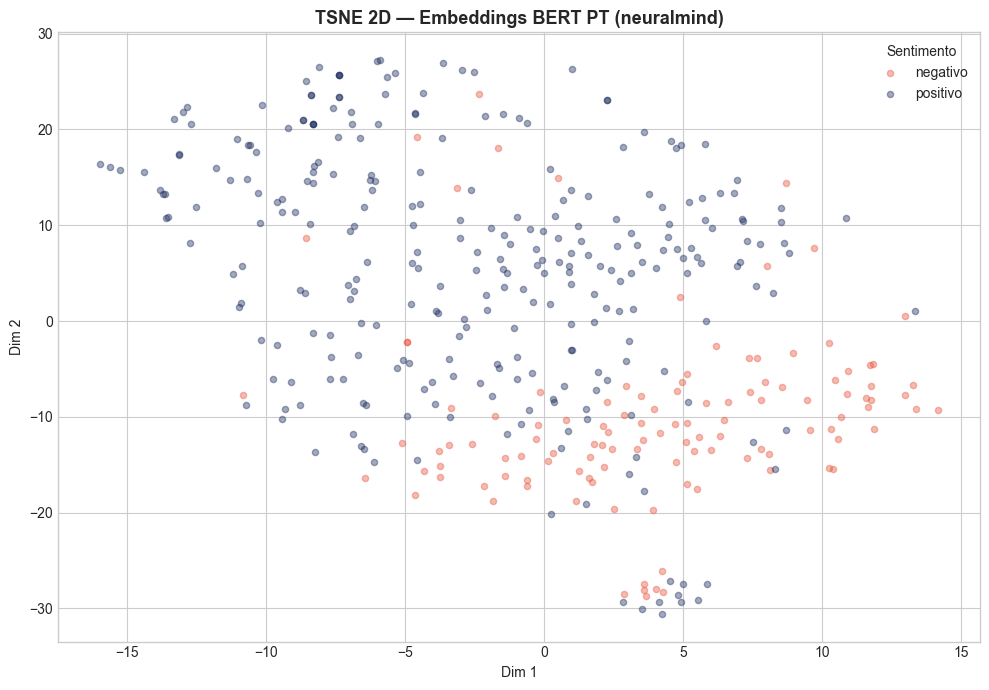

Observe: clusters mais nítidos que Word2Vec estático!


In [28]:
# ──  Embeddings contextuais ──────────────────────

MODELO_SBERT = 'neuralmind/bert-base-portuguese-cased'
print(f'Carregando {MODELO_SBERT}...')
sbert = SentenceTransformer(MODELO_SBERT)

print('Gerando embeddings treino/teste...')
t0 = time.time()
X_train_sbert = sbert.encode(list(X_train_raw), batch_size=32,
                              show_progress_bar=True, convert_to_numpy=True)
X_test_sbert  = sbert.encode(list(X_test_raw),  batch_size=32,
                              show_progress_bar=True, convert_to_numpy=True)
print(f'Concluido em {time.time()-t0:.1f}s | Shape: {X_train_sbert.shape}')

clf_sbert = LogisticRegression(max_iter=1000, random_state=42)
clf_sbert.fit(X_train_sbert, y_train)
y_pred_sbert = clf_sbert.predict(X_test_sbert)

acc_sbert = accuracy_score(y_test, y_pred_sbert)
f1_sbert  = f1_score(y_test, y_pred_sbert, average='weighted')
resultados['SBERT PT (M3)'] = {'acc': acc_sbert, 'f1': f1_sbert}
print(f'SBERT Acc: {acc_sbert*100:.2f}%  F1: {f1_sbert:.4f}')

# TSNE 2D
print('Gerando visualizacao TSNE 2D...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
emb_2d = tsne.fit_transform(X_test_sbert[:500])
labels_2d = y_test[:500]

fig, ax = plt.subplots(figsize=(10, 7))
for sent, cor in [('negativo','#E8553E'), ('positivo','#1B2B5E')]:
    mask = labels_2d == sent
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1], c=cor, alpha=0.4, s=20, label=sent)
ax.set_title('TSNE 2D — Embeddings BERT PT (neuralmind)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
ax.legend(title='Sentimento')
plt.tight_layout()
plt.savefig('m3_tsne_sbert.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observe: clusters mais nítidos que Word2Vec estático!')


## Parte 3- Resumo de notícias com BERT/BART Mt5

---

| Parte | O que fazemos | Modelo | Onde roda |
|---|---|---|---|
| **1** | Resumir uma notícia | BART multilingual (HuggingFace) | **Localmente** — sem API, sem custo |

## Modelo: `csebuetnlp/sshleifer/distilbart-cnn-12-6`

- Baseado em **cnn**
- Treinado no **XL-Sum dataset**: 1 milhão de artigos em 45 idiomas incluindo **português**
- Faz **resumo abstractivo** — não apenas extrai sentenças, reescreve o conteúdo
- Roda **100% localmente**, sem precisar de API key ou internet após o download
- Tamanho do modelo: ~580 MB (download na primeira execução, cache depois)
  
### Por que BART e não BERT puro para resumo?

BERT é um modelo **encoder-only** — excelente para entender e classificar texto, mas **não gera texto novo**.  
Para resumo **abstractivo** (reescrever com suas próprias palavras), precisamos de um modelo **encoder-decoder** como BART ou T5.  
Neste notebook usamos `csebuetnlp/mT5_multilingual_XLSum` — baseado em T5 e treinado em 45 idiomas incluindo **português**.

In [29]:
!pip install tiktoken transformers torch sentencepiece anthropic pandas python-dotenv --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import os
import re
import time
import warnings
import pandas as pd
import sentencepiece 
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas!')
print('transformers :', __import__('transformers').__version__)
print('anthropic    :', __import__('anthropic').__version__)

Bibliotecas carregadas!
transformers : 4.57.6
anthropic    : 0.89.0


In [31]:
import psutil, transformers
ram_gb = psutil.virtual_memory().available / 1024**3
print(f"RAM disponível: {ram_gb:.1f} GB")
print(f"transformers: {transformers.__version__}")

RAM disponível: 16.8 GB
transformers: 4.57.6


In [32]:
#pip install sentencepiece


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# ── Carregar o pipeline de sumarização ───────────────────────
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

#MODELO_RESUMO = 'csebuetnlp/mT5_multilingual_XLSum' #-> Funciona melhor em portugues mas localmente é muito pesado
MODELO_RESUMO = 'sshleifer/distilbart-cnn-12-6'

print(f'Carregando tokenizer (use_fast=False para compatibilidade com Python 3.9)...')
t0 = time.time()

# Carregar tokenizer e modelo separadamente
tokenizer_resumo = AutoTokenizer.from_pretrained(
    MODELO_RESUMO,
    use_fast=False  
)
modelo_resumo = AutoModelForSeq2SeqLM.from_pretrained(MODELO_RESUMO)

# Montar o pipeline com os objetos já carregados
resumidor = pipeline(
    'summarization',
    model=modelo_resumo,
    tokenizer=tokenizer_resumo,
    device=-1
)

print(f'Modelo pronto em {time.time()-t0:.1f}s')

Carregando tokenizer (use_fast=False para compatibilidade com Python 3.9)...


Device set to use cpu


Modelo pronto em 2.9s


In [34]:
# ── Função de resumo com controle de parâmetros ───────────────

# Token especial obrigatório para o mT5_multilingual_XLSum
# Indica ao modelo qual idioma deve gerar o resumo
WHITESPACE_HANDLER = lambda k: re.sub(r'\s+', ' ', re.sub(r'\n+', ' ', k.strip()))
LANG_TOKEN_PT = '<pt>'  # prefixo para português


def resumir(texto: str,
            max_length: int = 150,
            min_length: int = 40,
            idioma_token: str = LANG_TOKEN_PT) -> dict:
    """
    Resume um texto usando

    Parâmetros:
        texto       : texto da notícia (em português ou outro idioma)
        max_length  : máximo de tokens no resumo  (padrão: 150)
        min_length  : mínimo de tokens no resumo  (padrão: 40)
        idioma_token: token de idioma do modelo   (padrão: '<pt>')

    Retorna dict com:
        'resumo'          : o texto resumido
        'tokens_entrada'  : n.º de tokens da entrada
        'tokens_saida'    : n.º de tokens do resumo
        'reducao_pct'     : % de redução de tamanho
    """
    # Limpar o texto e adicionar token de idioma
    texto_limpo   = WHITESPACE_HANDLER(texto)
    texto_entrada = idioma_token + ' ' + texto_limpo

    # Gerar o resumo
    resultado = resumidor(
        texto_entrada,
        max_length=max_length,
        min_length=min_length,
        no_repeat_ngram_size=2,     # evita repetição de bigramas
        num_beams=4,                # beam search para melhor qualidade
        early_stopping=True,
        truncation=True
    )[0]['summary_text']

    tokens_entrada = len(texto_limpo.split())
    tokens_saida   = len(resultado.split())
    reducao        = (1 - tokens_saida / tokens_entrada) * 100

    return {
        'resumo'        : resultado,
        'tokens_entrada': tokens_entrada,
        'tokens_saida'  : tokens_saida,
        'reducao_pct'   : round(reducao, 1)
    }


print('Função resumir() pronta!')

Função resumir() pronta!


In [35]:
# ── Notícia de exemplo para resumir ──────────────────────────
# (substitua pelo texto de qualquer notícia real)

NOTICIA_PT = """
O governo federal anunciou nesta terça-feira um pacote de medidas econômicas
voltadas para estimular o crescimento do Produto Interno Bruto (PIB) nos próximos
dois anos. Entre as principais medidas, estão a redução da taxa de juros básica
da economia, o aumento dos investimentos em infraestrutura e a ampliação do
programa de crédito para micro e pequenas empresas.

O ministro da Fazenda destacou que as medidas devem gerar cerca de 500 mil novos
empregos até o final do ano e impulsionar o crescimento econômico para 3,5% ao
ano. O pacote também inclui incentivos fiscais para empresas que investirem em
tecnologia e inovação, além de desonerações para setores estratégicos como
agronegócio, exportações e turismo.

Economistas ouvidos pela imprensa avaliaram positivamente as medidas, mas
alertaram para riscos fiscais caso o governo não consiga controlar os gastos
públicos ao mesmo tempo. A bolsa de valores reagiu com alta de 2,3% após o
anúncio, com destaque para as ações do setor de construção civil, que subiram
mais de 5% em menos de uma hora de pregão.
"""

NOTICIA_EN = """
Brazil's federal government announced an economic stimulus package aimed at
boosting GDP growth over the next two years. The package includes cuts to
the benchmark interest rate, increased infrastructure spending, and expanded
credit lines for small and medium-sized businesses.

The Finance Minister said the measures are expected to create 500,000 new jobs
by year-end and push annual economic growth to 3.5%. The package also offers
tax incentives for technology and innovation investments, as well as relief
for strategic sectors such as agribusiness, exports, and tourism.

Economists generally welcomed the measures but warned of fiscal risks if the
government fails to control public spending simultaneously. The stock exchange
surged 2.3% following the announcement, with construction stocks jumping over
5% within an hour of trading.
"""

print('Notícias carregadas (PT e EN)')
print(f'Notícia PT: {len(NOTICIA_PT.split())} palavras')
print(f'Notícia EN: {len(NOTICIA_EN.split())} palavras')

Notícias carregadas (PT e EN)
Notícia PT: 171 palavras
Notícia EN: 123 palavras


In [45]:
# ── Resumir em Português ──────────────────────────────────────
print('Resumindo notícia em Português...')
t0 = time.time()
res_pt = resumir(NOTICIA_PT, max_length=120, min_length=30, idioma_token='<pt>')

SEP = '-' * 60
print(f'Tempo: {time.time()-t0:.1f}s')
print()
print(SEP)
print('TEXTO ORIGINAL (PT):')
print(SEP)
print(NOTICIA_PT.strip())
print()
print(SEP)
print('RESUMO GERADO (PT):')
print(SEP)
print(res_pt['resumo'])
print()
print(f'Tokens entrada : {res_pt["tokens_entrada"]}')
print(f'Tokens saída   : {res_pt["tokens_saida"]}')
print(f'Redução        : {res_pt["reducao_pct"]}%')

Resumindo notícia em Português...
Tempo: 13.1s

------------------------------------------------------------
TEXTO ORIGINAL (PT):
------------------------------------------------------------
O governo federal anunciou nesta terça-feira um pacote de medidas econômicas
voltadas para estimular o crescimento do Produto Interno Bruto (PIB) nos próximos
dois anos. Entre as principais medidas, estão a redução da taxa de juros básica
da economia, o aumento dos investimentos em infraestrutura e a ampliação do
programa de crédito para micro e pequenas empresas.

O ministro da Fazenda destacou que as medidas devem gerar cerca de 500 mil novos
empregos até o final do ano e impulsionar o crescimento econômico para 3,5% ao
ano. O pacote também inclui incentivos fiscais para empresas que investirem em
tecnologia e inovação, além de desonerações para setores estratégicos como
agronegócio, exportações e turismo.

Economistas ouvidos pela imprensa avaliaram positivamente as medidas, mas
alertaram para r

In [46]:
# ── Resumir em Inglês ─────────────────────────────────────────
print('Resumindo notícia em Inglês...')
t0 = time.time()
res_en = resumir(NOTICIA_EN, max_length=300, min_length=120, idioma_token='<english>')

print(f'Tempo: {time.time()-t0:.1f}s')
print()
print(SEP)
print('RESUMO GERADO (EN):')

print(SEP)
print(res_en['resumo'])
print(f'Tokens entrada : {res_en["tokens_entrada"]}')
print(f'Tokens saída   : {res_en["tokens_saida"]}')
print(f'Redução: {res_en["reducao_pct"]}%')

Your max_length is set to 300, but your input_length is only 157. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=78)


Resumindo notícia em Inglês...
Tempo: 12.4s

------------------------------------------------------------
RESUMO GERADO (EN):
------------------------------------------------------------
 Brazil's federal government announced an economic stimulus package aimed at boosting GDP growth over the next two years . Package includes cuts to the benchmark interest rate, increased infrastructure spending, and expanded credit lines for small and medium-sized businesses . The Finance Minister said the measures are expected to create 500,000 new jobs by year-end and push annual economic growth to 3.5%. The stock exchange surged 2.3% following the announcement, with construction stocks jumping over 5% within an hour of trading . Economists generally welcomed the package but warned of fiscal risks if the government fails to control public spending simultaneously .
Tokens entrada : 123
Tokens saída   : 102
Redução: 17.1%


## Parte 3.1- Resumo de notícias com BERT/BART Mt5 Via api

In [38]:
import requests

#HF_TOKEN = "Seu token"   # gratuito em huggingface.co/settings/tokens

def resumir_hf_requests(texto):
    # Nova URL: router.huggingface.co/hf-inference/models/{modelo}
    url = "https://router.huggingface.co/hf-inference/models/csebuetnlp/mT5_multilingual_XLSum"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"}
    payload = {
        "inputs": texto[:1024],
        "parameters": {"max_length": 300, "min_length": 60}
    }
    r = requests.post(url, headers=headers, json=payload, timeout=60)
    if r.status_code == 200:
        return r.json()[0]["summary_text"]
    elif r.status_code == 503:
        return "[Modelo aquecendo — tente novamente em 20s]"
    else:
        return f"[Erro {r.status_code}: {r.text[:150]}]"

In [47]:
texto_teste =  """
O governo federal anunciou nesta terça-feira um pacote de medidas econômicas
voltadas para estimular o crescimento do Produto Interno Bruto (PIB) nos próximos
dois anos. Entre as principais medidas, estão a redução da taxa de juros básica
da economia, o aumento dos investimentos em infraestrutura e a ampliação do
programa de crédito para micro e pequenas empresas.

O ministro da Fazenda destacou que as medidas devem gerar cerca de 500 mil novos
empregos até o final do ano e impulsionar o crescimento econômico para 3,5% ao
ano. O pacote também inclui incentivos fiscais para empresas que investirem em
tecnologia e inovação, além de desonerações para setores estratégicos como
agronegócio, exportações e turismo.

Economistas ouvidos pela imprensa avaliaram positivamente as medidas, mas
alertaram para riscos fiscais caso o governo não consiga controlar os gastos
públicos ao mesmo tempo. A bolsa de valores reagiu com alta de 2,3% após o
anúncio, com destaque para as ações do setor de construção civil, que subiram
mais de 5% em menos de uma hora de pregão.
"""
print(resumir_hf_requests(texto_teste))

A bolsa de valores voltou a subir nesta terça-feira em meio às medidas anunciadas pelo governo federal para estimular o crescimento da economia brasileira, com destaque para as ações do setor de construção civil.


## Parte 4 Classificação de reviews com Claude API

---

| Parte | O que fazemos | Modelo | Onde roda |
|---|---|---|---|
| **2** | Classificar reviews Olist | Claude Haiku 4.5 (Anthropic) | **Na nuvem** — via API (requer key) |

## Modelo: `claude-haiku-4-5` (Anthropic)

| Aspecto | Detalhe |
|---|---|
| **Modelo** | `claude-haiku-4-5` — mais rápido e econômico da família Claude 4 |
| **SDK** | `anthropic` — oficial da Anthropic |
| **Endpoint** | `https://api.anthropic.com/v1/messages` |
| **Autenticação** | `ANTHROPIC_API_KEY` no environment ou `.env` |
| **Onde obter a key** | https://console.anthropic.com → API Keys |

### Estrutura da chamada
```python
client.messages.create(
    model     = 'claude-haiku-4-5',   # modelo a usar
    max_tokens= 100,                   # limite da resposta
    system    = '...',                 # instruções globais do assistente
    messages  = [                      # conversa
        {"role": "user", "content": "..."}
    ]
)
```


In [40]:
# ── Configurar a API key ───────────────────────────────────
#   Criar arquivo .env na pasta do notebook
#   Crie um arquivo chamado .env com o conteúdo:
#   ANTHROPIC_API_KEY=sk-ant-...

from dotenv import load_dotenv
load_dotenv()
import anthropic

ANTHROPIC_KEY = os.getenv('ANTHROPIC_API_KEY', '')
API_DISPONIVEL = len(ANTHROPIC_KEY) > 10

if API_DISPONIVEL:
    client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    print('Cliente Anthropic criado com sucesso!')
    print('Modelo que usaremos: claude-haiku-4-5')
else:
    print('ANTHROPIC_API_KEY nao encontrada.')
    print('Configure a variavel de ambiente ou o arquivo .env')
    print('Obtenha sua key em: https://console.anthropic.com')
    print()
    print('As celulas de exemplo serao executadas com mock para demonstracao.')

Cliente Anthropic criado com sucesso!
Modelo que usaremos: claude-haiku-4-5


In [41]:
# ── Carregar os reviews Olist ─────────────────────────────────
df = pd.read_csv('olist_order_reviews_dataset.csv')
df_texto = df[
    df['review_comment_message'].notna() &
    (df['review_comment_message'].str.strip() != '')
].reset_index(drop=True)

print(f'Reviews com texto: {len(df_texto):,}')
print('Exemplos:')
for _, row in df_texto.sample(3, random_state=42).iterrows():
    print(f'  [{row["review_score"]}*] {row["review_comment_message"][:70]}...')

Reviews com texto: 41,726
Exemplos:
  [4*] A targaryen entregou bem antes do prazo, O produto ainda não vi mandei...
  [5*] Otimo...
  [4*] otima
...


In [42]:
# ── Função principal: classificar_review() ───────────────────

SYSTEM_PROMPT = """
Você é um especialista em análise de sentimento de reviews de e-commerce brasileiros.
Sua tarefa é classificar o sentimento de reviews de clientes.

Regras:
- Responda APENAS com um objeto JSON válido, sem markdown, sem texto adicional
- O JSON deve ter exatamente 3 campos: "sentimento", "confianca", "justificativa"
- "sentimento": deve ser exatamente "positivo", "negativo" ou "neutro"
- "confianca": número de 0.0 a 1.0 indicando sua certeza
- "justificativa": frase curta (máx. 15 palavras) explicando o motivo
"""


def classificar_review(texto: str, verbose: bool = False) -> dict:
    """
    Classifica o sentimento de um review Olist usando Claude Haiku 4.5.

    Retorna dict com:
        sentimento   : 'positivo', 'negativo' ou 'neutro'
        confianca    : float 0.0–1.0
        justificativa: string
        tokens_usados: dict com input_tokens e output_tokens
    """
    import json

    if not API_DISPONIVEL:
        # Mock para demonstração sem API key
        txt = texto.lower()
        if any(w in txt for w in ['otimo','excelente','adorei','rapido','perfeito','amei']):
            return {'sentimento':'positivo','confianca':0.95,'justificativa':'Mock: palavras muito positivas detectadas','tokens_usados':{'input':0,'output':0}}
        elif any(w in txt for w in ['pessimo','defeito','atrasou','ruim','terrivel','decepcionante']):
            return {'sentimento':'negativo','confianca':0.92,'justificativa':'Mock: palavras negativas detectadas','tokens_usados':{'input':0,'output':0}}
        else:
            return {'sentimento':'neutro','confianca':0.70,'justificativa':'Mock: sem indicadores claros de sentimento','tokens_usados':{'input':0,'output':0}}

    # ── Chamada real à API Claude ─────────────────────────────
    user_message = f'Classifique o sentimento deste review:\n\n"{texto}"'

    resposta = client.messages.create(
        model      = 'claude-haiku-4-5',   # modelo mais rápido e econômico
        max_tokens = 150,                   # JSON pequeno — não precisa de muito
        system     = SYSTEM_PROMPT,         # instruções no system role
        messages   = [
            {"role": "user", "content": user_message}
        ]
    )

    # ── Extrair e parsear o JSON da resposta ──────────────────
    texto_resposta = resposta.content[0].text.strip()

    # Remover possíveis ```json ... ``` se o modelo adicionou
    texto_resposta = re.sub(r'^```json\s*|^```\s*|\s*```$', '', texto_resposta, flags=re.MULTILINE)

    resultado = json.loads(texto_resposta)
    resultado['tokens_usados'] = {
        'input' : resposta.usage.input_tokens,
        'output': resposta.usage.output_tokens
    }

    if verbose:
        print(f'Resposta bruta da API: {texto_resposta}')
        print(f'Tokens usados: {resultado["tokens_usados"]}')

    return resultado


print('Função classificar_review() pronta!')
print(f'Modo: {"API Claude real" if API_DISPONIVEL else "Mock (sem API key)"}')

Função classificar_review() pronta!
Modo: API Claude real


In [48]:
# ── Teste com 1 review — ver resposta completa ────────────────
review_teste = df_texto.sample(1, random_state=7).iloc[0]

print('REVIEW DE TESTE:')
print(f'Nota real  : {review_teste["review_score"]}★')
print(f'Texto      : {review_teste["review_comment_message"]}')
print()

resultado = classificar_review(review_teste['review_comment_message'], verbose=True)

print()
print('RESULTADO DO CLAUDE:')
print(f'  Sentimento   : {resultado["sentimento"]}')
print(f'  Confiança    : {resultado["confianca"]*100:.0f}%')
print(f'  Justificativa: {resultado["justificativa"]}')

# Comparar com a nota real
nota = review_teste['review_score']
sentimento_real = 'positivo' if nota >= 4 else 'negativo' if nota <= 2 else 'neutro'
acertou = resultado['sentimento'] == sentimento_real
print(f'\nSentimento real (da nota {nota}★): {sentimento_real}')
print(f'Claude acertou? {"SIM ✅" if acertou else "NAO ❌"}')

REVIEW DE TESTE:
Nota real  : 5★
Texto      : Linda cortina, ótimo material.

Resposta bruta da API: {"sentimento": "positivo", "confianca": 0.95, "justificativa": "Elogios diretos ao produto: linda e ótimo material."}
Tokens usados: {'input': 197, 'output': 49}

RESULTADO DO CLAUDE:
  Sentimento   : positivo
  Confiança    : 95%
  Justificativa: Elogios diretos ao produto: linda e ótimo material.

Sentimento real (da nota 5★): positivo
Claude acertou? SIM ✅


In [50]:
# ── Classificar lote de reviews com controle de rate limit ───

def classificar_lote(
    df_reviews: pd.DataFrame,
    n: int = 30,
    delay_s: float = 0.5,   # espera entre chamadas (respeitar rate limit)
    random_state: int = 42
) -> pd.DataFrame:
    """
    Classifica um lote de reviews e retorna DataFrame com resultados.
    delay_s controla o intervalo entre chamadas (evitar rate limit).
    """
    amostra = df_reviews.sample(n=min(n, len(df_reviews)), random_state=random_state)
    resultados = []

    print(f'Classificando {len(amostra)} reviews com Claude Haiku 4.5...')
    print(f'(aguardando {delay_s}s entre chamadas)')

    for i, (_, row) in enumerate(amostra.iterrows(), 1):
        texto = row['review_comment_message']
        nota  = row['review_score']

        try:
            res = classificar_review(texto)
            resultados.append({
                'texto'           : texto[:80] + '...',
                'nota_real'       : nota,
                'sentimento_real' : 'positivo' if nota >= 4 else ('negativo' if nota <= 2 else 'neutro'),
                'sentimento_claude': res['sentimento'],
                'confianca'       : res['confianca'],
                'justificativa'   : res['justificativa'],
                'tokens_input'    : res['tokens_usados']['input'],
                'tokens_output'   : res['tokens_usados']['output'],
            })
            # Feedback de progresso
            acertou = res['sentimento'] == resultados[-1]['sentimento_real']
            print(f'  [{i:02d}/{len(amostra)}] nota={nota}★  '
                  f'claude={res["sentimento"]:10s}  '
                  f'confiança={res["confianca"]*100:.0f}%  '
                  f'{"✅" if acertou else "❌"}')

        except Exception as e:
            print(f'  [{i:02d}] ERRO: {e}')
            resultados.append({'texto':texto[:80]+'...','nota_real':nota,
                               'sentimento_real':'?','sentimento_claude':'erro',
                               'confianca':0,'justificativa':str(e),
                               'tokens_input':0,'tokens_output':0})

        # Aguardar para não estourar o rate limit
        if i < len(amostra) and API_DISPONIVEL:
            time.sleep(delay_s)

    return pd.DataFrame(resultados)


# Executar — use n=5 para teste rápido, n=20 para análise completa
df_resultado = classificar_lote(df_texto, n=50, delay_s=0.2)

Classificando 50 reviews com Claude Haiku 4.5...
(aguardando 0.2s entre chamadas)
  [01/50] nota=4★  claude=positivo    confiança=85%  ✅
  [02/50] nota=5★  claude=positivo    confiança=95%  ✅
  [03/50] nota=4★  claude=positivo    confiança=85%  ✅
  [04/50] nota=5★  claude=positivo    confiança=95%  ✅
  [05/50] nota=5★  claude=positivo    confiança=95%  ✅
  [06/50] nota=1★  claude=negativo    confiança=85%  ✅
  [07/50] nota=5★  claude=positivo    confiança=95%  ✅
  [08/50] nota=5★  claude=positivo    confiança=75%  ✅
  [09/50] nota=5★  claude=positivo    confiança=92%  ✅
  [10/50] nota=1★  claude=negativo    confiança=95%  ✅
  [11/50] nota=4★  claude=neutro      confiança=75%  ❌
  [12/50] nota=1★  claude=negativo    confiança=95%  ✅
  [13/50] nota=1★  claude=negativo    confiança=95%  ✅
  [14/50] nota=1★  claude=negativo    confiança=95%  ✅
  [15/50] nota=5★  claude=positivo    confiança=95%  ✅
  [16/50] nota=5★  claude=positivo    confiança=85%  ✅
  [17/50] nota=5★  claude=positivo    